# Generate distribution plots for features used to detect poor quality segmentations

This code is derived from the `cellpainting_predicts_cardiac_fibrosis` repository.

In [1]:
import pathlib

import numpy as np
import pandas as pd
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_bar,
    geom_density,
    geom_point,
    geom_text,
    ggplot,
    labs,
    position_dodge,
    scale_color_manual,
    scale_fill_manual,
    theme,
    theme_bw,
    xlim,
    ylim,
)
from plotnine.options import set_option
from pycytominer import annotate

from cosmicqc import find_outliers

In [2]:
# Directory with data
data_dir = pathlib.Path(
    "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/converted_profiles/"
)

# Directory with plate maps
metadata_dir = pathlib.Path(
    "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/metadata/"
)

# Directory to save figures
figure_dir = pathlib.Path("./figures")
figure_dir.mkdir(exist_ok=True)

plate_names = [
    "localhost230405150001",
    "localhost231120090001",
]

plate_paths = {
    plate_name: data_dir / f"{plate_name}_converted.parquet"
    for plate_name in plate_names
}

platemap_paths = {
    plate_name: metadata_dir / f"{plate_name}_platemap.csv"
    for plate_name in plate_names
}

# Metadata columns to keep in QC summary outputs.
metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
]

In [3]:
# Load all converted plate data.
plate_dfs = {
    plate_name: pd.read_parquet(plate_path)
    for plate_name, plate_path in plate_paths.items()
}

# Update plate names with alias for better readability in plots
plate_name_aliases = {
    "localhost230405150001": "Retransplantation plate",
    "localhost231120090001": "IDC plate",
}
# Update plate name column in dataframes
plate_dfs = {
    key: df.assign(
        Image_Metadata_Plate_Alias=df["Image_Metadata_Plate"].replace(
            plate_name_aliases
        )
    )
    for key, df in plate_dfs.items()
}

for plate_name, df in plate_dfs.items():
    print(f"{plate_name}: {df.shape}")

plate_df = pd.concat(plate_dfs.values(), ignore_index=True)
print(f"combined: {plate_df.shape}")
plate_df.head()

localhost230405150001: (25859, 2017)
localhost231120090001: (20856, 2017)
combined: (46715, 2017)


,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,Metadata_Image_Count_Cells,Metadata_ImageNumber,Image_Metadata_Plate,Image_Metadata_Site,Image_Metadata_Well,Metadata_Cells_Number_Object_Number,...,Nuclei_Texture_Variance_Hoechst_3_03_256,Nuclei_Texture_Variance_Mitochondria_3_00_256,Nuclei_Texture_Variance_Mitochondria_3_01_256,Nuclei_Texture_Variance_Mitochondria_3_02_256,Nuclei_Texture_Variance_Mitochondria_3_03_256,Nuclei_Texture_Variance_PM_3_00_256,Nuclei_Texture_Variance_PM_3_01_256,Nuclei_Texture_Variance_PM_3_02_256,Nuclei_Texture_Variance_PM_3_03_256,Image_Metadata_Plate_Alias
0,221.046761,137.115493,246.602800,109.285755,40,1,localhost230405150001,f00,B02,1,...,2.938125,0.529422,0.478064,0.489459,0.475133,2.703146,2.664110,2.650578,2.664691,Retransplantation plate
1,690.596142,183.067828,716.170091,177.132195,40,1,localhost230405150001,f00,B02,2,...,2.551946,46.883295,50.496897,42.311975,39.973584,4.376776,4.567953,4.220630,4.058367,Retransplantation plate
2,626.561490,206.923698,623.943740,199.906440,40,1,localhost230405150001,f00,B02,3,...,1.430094,0.970588,0.952145,0.950279,0.908622,2.568485,2.578927,2.556851,2.541355,Retransplantation plate
3,559.448583,220.688160,528.646623,196.955552,40,1,localhost230405150001,f00,B02,4,...,2.660096,2.511639,2.456358,2.509622,2.547159,3.866945,4.011720,4.004412,3.866034,Retransplantation plate
4,909.019946,247.694340,897.965996,253.621836,40,1,localhost230405150001,f00,B02,5,...,1.629242,5.823674,6.553608,6.620230,5.453092,2.029099,2.044566,2.038007,2.058557,Retransplantation plate


In [17]:
overseg_feature_thresholds = {
    "Nuclei_AreaShape_Area": 2,
    "Nuclei_Intensity_IntegratedIntensity_Hoechst": 2,
}

# Define threshold for one plate (will be overrided for other plate in function)
small_cells_feature_thresholds = {
    "Cells_AreaShape_Area": -1,
}

outlier_thresholds_dict = {
    "over-segmented_nuclei": overseg_feature_thresholds,
    "small_cells": small_cells_feature_thresholds,
}

qc_colors = {
    "Single-cell passed QC": "#006400",
    "Single-cell failed QC": "#990090",
}

qc_type_colors = {
    "Under-segmented nuclei": "#1D3557",
    "Mis-segmented cells": "#E63946",
    "Single-cell passed QC": "#2A9D8F",
}

In [5]:
def thresholds_for_plate(plate_name, feature_thresholds):
    """Return a fresh threshold config with any plate-specific overrides."""
    thresholds = {
        key: value.copy() if isinstance(value, dict) else value
        for key, value in feature_thresholds.items()
    }

    if plate_name == "localhost230405150001":
        if "Cells_AreaShape_Area" in thresholds:
            thresholds["Cells_AreaShape_Area"] = -0.9

        for condition_thresholds in thresholds.values():
            if (
                isinstance(condition_thresholds, dict)
                and "Cells_AreaShape_Area" in condition_thresholds
            ):
                condition_thresholds["Cells_AreaShape_Area"] = -0.9

    return thresholds


def find_outliers_by_plate(plate_dfs, feature_thresholds):
    outlier_dfs = []

    for plate_name, df in plate_dfs.items():
        print(f"\n{plate_name}")

        thresholds = thresholds_for_plate(plate_name, feature_thresholds)

        outlier_dfs.append(
            find_outliers(
                df=df,
                metadata_columns=metadata_columns,
                feature_thresholds=thresholds,
            )
        )

    return pd.concat(outlier_dfs)


def add_outlier_status(plate_df, outliers_df):
    """Add a column to the plate dataframe indicating whether each single cell
    is an outlier or not, based on the outliers dataframe."""
    cols = [
        "Image_Metadata_Plate",
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Metadata_Nuclei_Location_Center_X",
        "Metadata_Nuclei_Location_Center_Y",
    ]

    outlier_keys = outliers_df[cols].drop_duplicates().assign(_is_outlier=1)

    plot_df = plate_df.merge(outlier_keys, on=cols, how="left")

    plot_df["Outlier_Status"] = np.where(
        plot_df["_is_outlier"].eq(1),
        "Single-cell failed QC",
        "Single-cell passed QC",
    )

    return plot_df.drop(columns=["_is_outlier"])


def label_outliers_by_plate(plate_dfs, condition_outliers):
    """Label each cell from the already-computed per-condition outlier results."""
    labelled_dfs = []
    metadata_cols = [
        "Image_Metadata_Plate",
        "Image_Metadata_Plate_Alias",
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Metadata_Nuclei_Location_Center_X",
        "Metadata_Nuclei_Location_Center_Y",
    ]

    outlier_key_cols = [
        "Image_Metadata_Plate",
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Metadata_Nuclei_Location_Center_X",
        "Metadata_Nuclei_Location_Center_Y",
    ]

    for _, df in plate_dfs.items():
        labelled_df = df[metadata_cols].copy()

        for condition_name, outliers_df in condition_outliers.items():
            outlier_keys = (
                outliers_df[outlier_key_cols].drop_duplicates().assign(_is_outlier=True)
            )
            labelled_df = labelled_df.merge(
                outlier_keys,
                on=outlier_key_cols,
                how="left",
            )
            # Add cqc columns for each condition like label_outliers function
            cqc_column = f"Metadata_cqc_{condition_name}_is_outlier"
            labelled_df[cqc_column] = (
                labelled_df.pop("_is_outlier").astype("boolean").fillna(False)
            )

        labelled_dfs.append(labelled_df)

    return pd.concat(labelled_dfs, ignore_index=True)


def annotate_by_plate(df, platemap_paths):
    """Add only condition metadata from each plate map."""
    annotated_dfs = []

    for plate_name, plate_df in df.groupby("Image_Metadata_Plate", sort=False):
        print(f"Annotating {plate_name}...")
        platemap_df = pd.read_csv(platemap_paths[plate_name])
        annotated_dfs.append(
            annotate(
                profiles=plate_df,
                platemap=platemap_df,
                join_on=[
                    "Metadata_well_position",
                    "Image_Metadata_Well",
                ],
            )
        )

    return pd.concat(annotated_dfs, ignore_index=True)


def make_condition_label(df):
    """Use treatment labels when available; otherwise heart number and cell type."""
    condition_df = df.copy()
    treatment = condition_df["Metadata_treatment"].fillna("").astype(str).str.strip()
    cell_type = condition_df["Metadata_cell_type"].astype(str).str.strip()
    heart_number = condition_df["Metadata_heart_number"].astype(str).str.strip()

    condition_df["condition"] = np.where(
        treatment.ne(""),
        treatment + " | " + cell_type,
        "heart " + heart_number + " | " + cell_type,
    )

    return condition_df

In [6]:
large_nuclei_high_int_outliers = find_outliers_by_plate(
    plate_dfs=plate_dfs,
    feature_thresholds=overseg_feature_thresholds,
)

print(large_nuclei_high_int_outliers.shape)
large_nuclei_high_int_outliers.head()


localhost230405150001
Number of outliers: 444 (1.72%)
Outliers Range:
Nuclei_AreaShape_Area Min: 2615.0
Nuclei_AreaShape_Area Max: 7604.0
Nuclei_Intensity_IntegratedIntensity_Hoechst Min: 150.04394634626806
Nuclei_Intensity_IntegratedIntensity_Hoechst Max: 836.8383014723659

localhost231120090001
Number of outliers: 385 (1.85%)
Outliers Range:
Nuclei_AreaShape_Area Min: 1893.0
Nuclei_AreaShape_Area Max: 7461.0
Nuclei_Intensity_IntegratedIntensity_Hoechst Min: 108.5163960903883
Nuclei_Intensity_IntegratedIntensity_Hoechst Max: 644.2570542618632
(829, 7)


,Nuclei_AreaShape_Area,Nuclei_Intensity_IntegratedIntensity_Hoechst,Image_Metadata_Plate,Image_Metadata_Well,Image_Metadata_Site,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y
37,3990.0,154.616541,localhost230405150001,B02,f00,177.249624,983.235589
107,4179.0,191.951339,localhost230405150001,B02,f03,51.247428,222.126346
154,6340.0,258.128116,localhost230405150001,B02,f04,621.836751,421.906940
234,2975.0,158.979675,localhost230405150001,B02,f07,41.622185,178.953950
258,4291.0,266.441139,localhost230405150001,B02,f07,619.858774,616.496854


In [7]:
large_nuclei_high_int_outliers["Image_Metadata_Plate"].value_counts()

Image_Metadata_Plate
localhost230405150001    444
localhost231120090001    385
Name: count, dtype: int64

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 4 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/distribution_nuclei_outliers.png


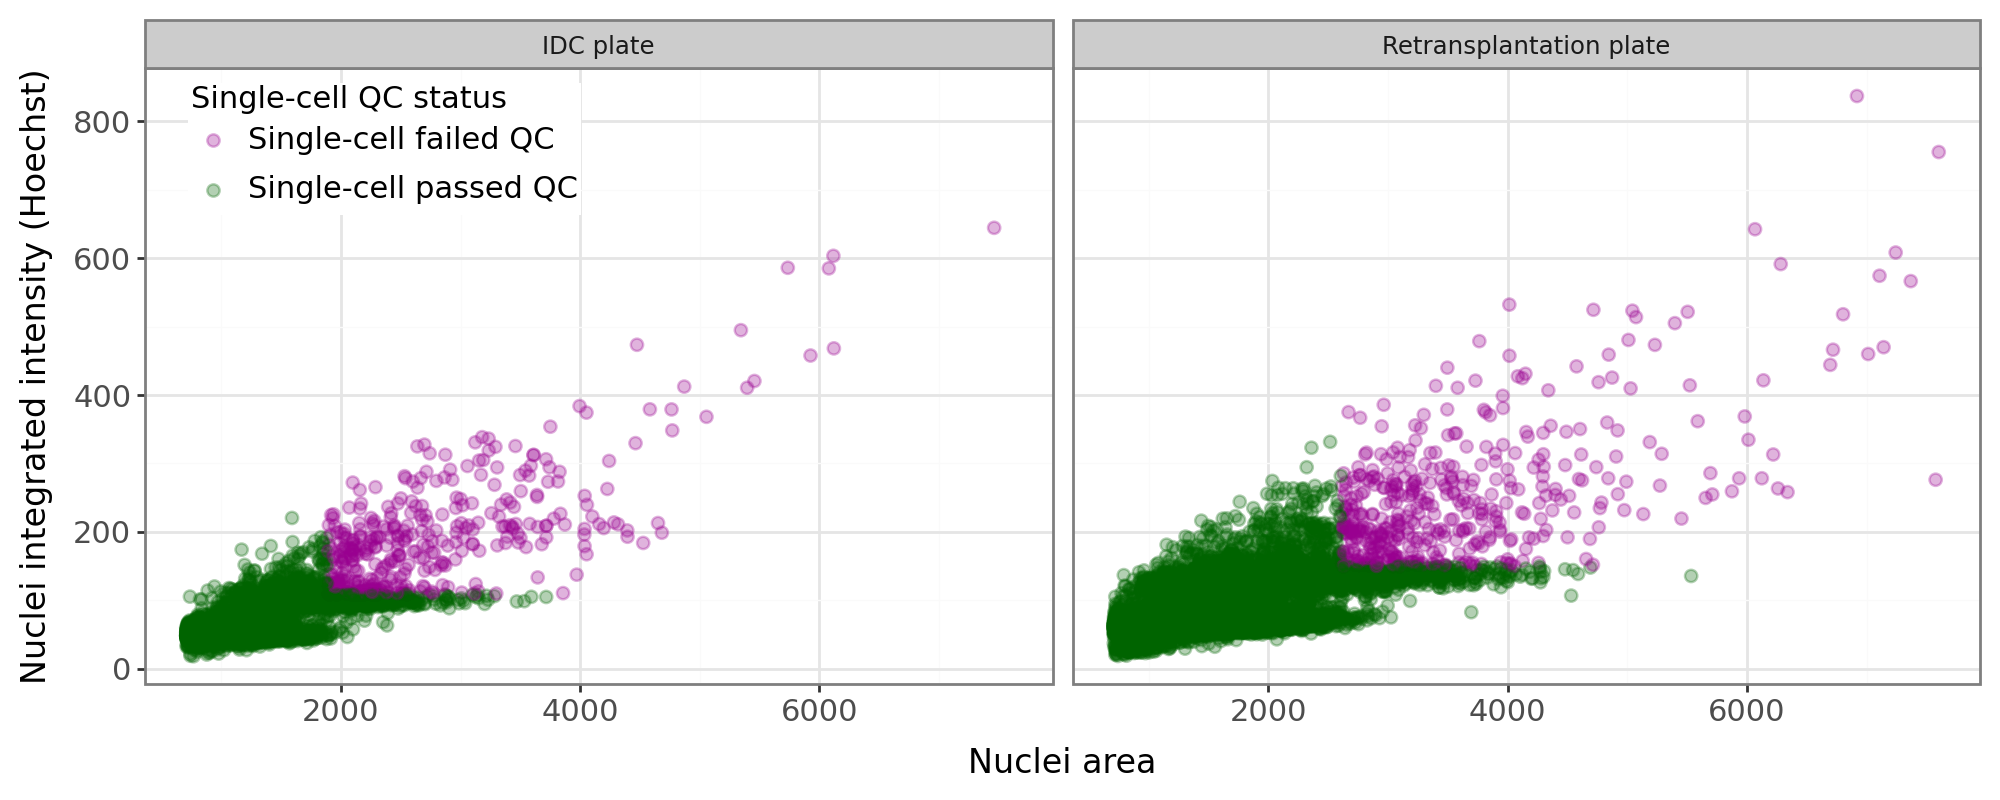

In [8]:
plate_df_overseg = add_outlier_status(
    plate_df=plate_df,
    outliers_df=large_nuclei_high_int_outliers,
)

height = 4
width = 10
set_option("figure_size", (width, height))

p = (
    ggplot(
        plate_df_overseg,
        aes(
            x="Nuclei_AreaShape_Area",
            y="Nuclei_Intensity_IntegratedIntensity_Hoechst",
            color="Outlier_Status",
        ),
    )
    + geom_point(alpha=0.3, size=2)
    + facet_wrap("Image_Metadata_Plate_Alias", ncol=2)
    + scale_color_manual(values=qc_colors)
    + labs(
        x="Nuclei area",
        y="Nuclei integrated intensity (Hoechst)",
        color="Single-cell QC status",
    )
    + theme_bw()
    + theme(
        legend_position=(0.03, 0.97),
        legend_direction="vertical",
        legend_text=element_text(size=11),
        axis_title=element_text(size=12),
        axis_text=element_text(size=11),
    )
)

p.save(
    f"{figure_dir}/distribution_nuclei_outliers.png",
    dpi=500,
    width=width,
    height=height,
)

p.show()

In [9]:
small_cells_outliers = find_outliers_by_plate(
    plate_dfs=plate_dfs,
    feature_thresholds=small_cells_feature_thresholds,
)

print(small_cells_outliers.shape)
small_cells_outliers.sort_values(by="Cells_AreaShape_Area", ascending=False).head()


localhost230405150001
Number of outliers: 4553 (17.61%)
Outliers Range:
Cells_AreaShape_Area Min: 708.0
Cells_AreaShape_Area Max: 2866.0

localhost231120090001
Number of outliers: 3633 (17.42%)
Outliers Range:
Cells_AreaShape_Area Min: 708.0
Cells_AreaShape_Area Max: 2641.0
(8186, 6)


,Cells_AreaShape_Area,Image_Metadata_Plate,Image_Metadata_Well,Image_Metadata_Site,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y
6160,2866.0,localhost230405150001,C04,f03,442.290237,793.576517
79,2865.0,localhost230405150001,B02,f02,678.568528,405.227157
25164,2865.0,localhost230405150001,G10,f00,101.571025,469.293993
9770,2864.0,localhost230405150001,D03,f00,780.812500,614.543440
18866,2864.0,localhost230405150001,E10,f06,262.386059,854.742627


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 4 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/distribution_cells_outliers.png


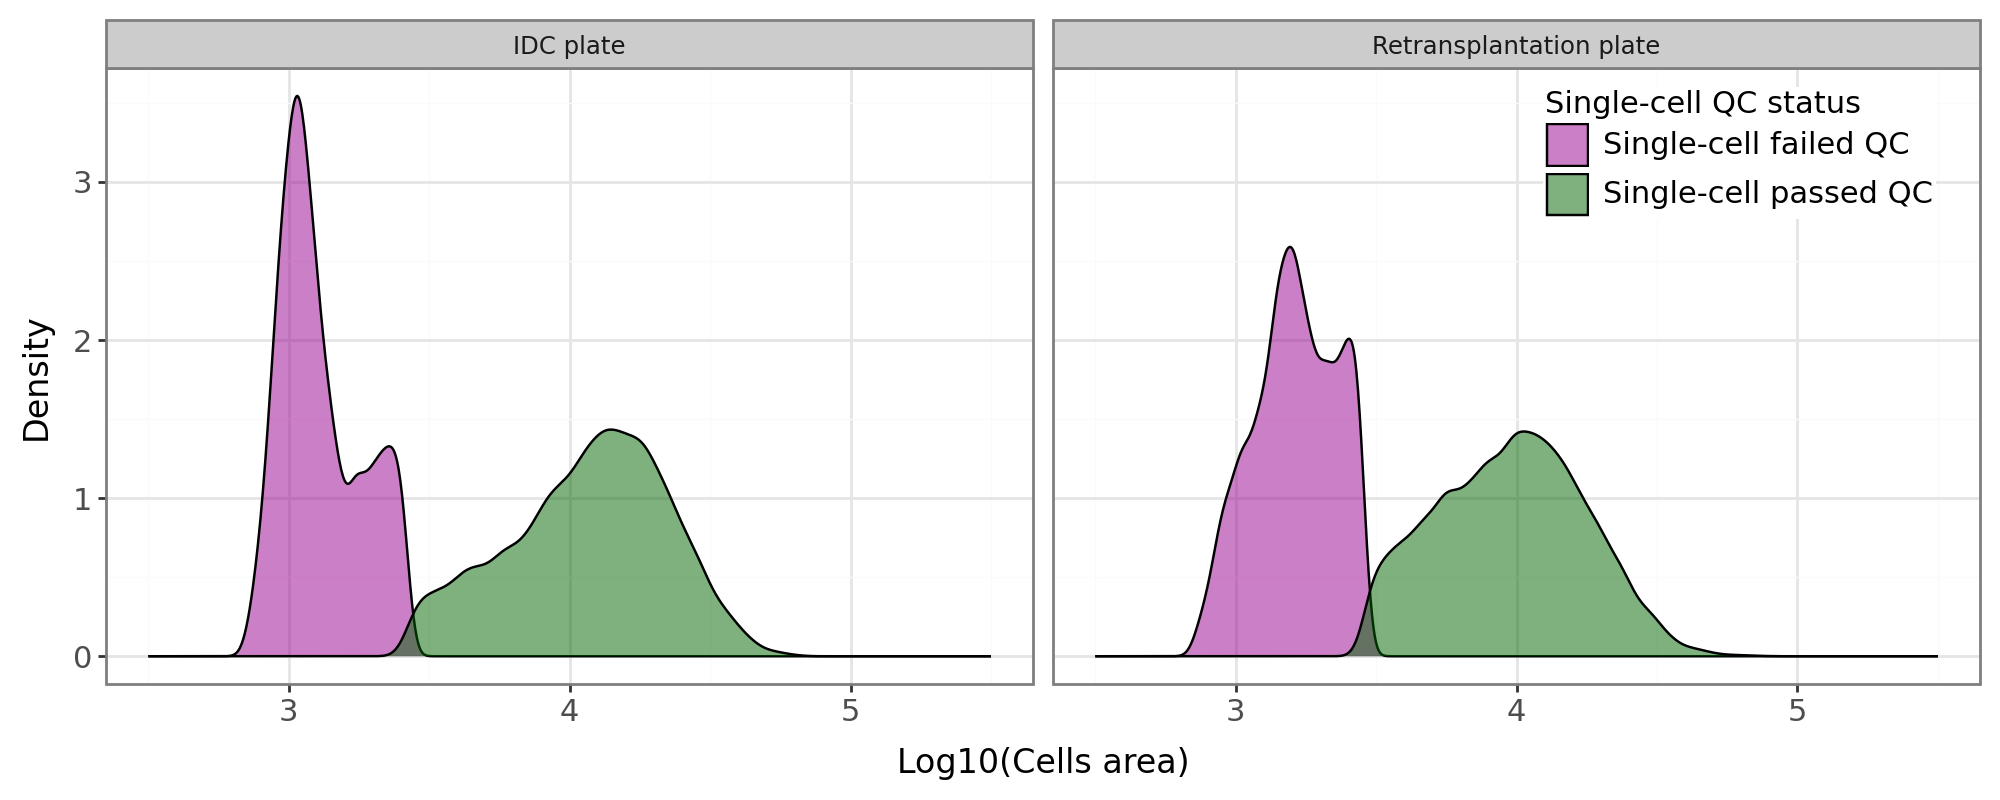

In [10]:
plate_df_small_cells = add_outlier_status(
    plate_df=plate_df,
    outliers_df=small_cells_outliers,
)

plate_df_small_cells["Log_Cells_Area"] = np.log10(
    plate_df_small_cells["Cells_AreaShape_Area"]
)

height = 4
width = 10
set_option("figure_size", (width, height))

p = (
    ggplot(plate_df_small_cells, aes(x="Log_Cells_Area", fill="Outlier_Status"))
    + geom_density(alpha=0.5)
    + facet_wrap("Image_Metadata_Plate_Alias", ncol=2)
    + scale_fill_manual(values=qc_colors)
    + labs(x="Log10(Cells area)", y="Density", fill="Single-cell QC status")
    + theme_bw()
    + xlim(2.5, 5.5)
    + theme(
        legend_position=(0.97, 0.96),
        legend_text=element_text(size=11),
        axis_title=element_text(size=12),
        axis_text=element_text(size=11),
    )
)

p.save(
    f"{figure_dir}/distribution_cells_outliers.png",
    dpi=500,
    width=width,
    height=height,
)

p.show()

In [11]:
plate_df_outliers = label_outliers_by_plate(
    plate_dfs=plate_dfs,
    condition_outliers={
        "under_segmented_nuclei": large_nuclei_high_int_outliers,
        "mis_segmented_cells": small_cells_outliers,
    },
)

plate_df_outliers = annotate_by_plate(
    df=plate_df_outliers,
    platemap_paths=platemap_paths,
)

print(plate_df_outliers.shape)
plate_df_outliers.head()

Annotating localhost230405150001...
Annotating localhost231120090001...
(46715, 14)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Plate,Metadata_Well,Metadata_Site,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_cqc_under_segmented_nuclei_is_outlier,Metadata_cqc_mis_segmented_cells_is_outlier,Image_Metadata_Plate_Alias
0,B,2,9,failing,rejected,DMSO,localhost230405150001,B02,f00,221.046761,137.115493,False,False,Retransplantation plate
1,B,2,9,failing,rejected,DMSO,localhost230405150001,B02,f00,690.596142,183.067828,False,False,Retransplantation plate
2,B,2,9,failing,rejected,DMSO,localhost230405150001,B02,f00,626.561490,206.923698,False,False,Retransplantation plate
3,B,2,9,failing,rejected,DMSO,localhost230405150001,B02,f00,559.448583,220.688160,False,False,Retransplantation plate
4,B,2,9,failing,rejected,DMSO,localhost230405150001,B02,f00,909.019946,247.694340,False,False,Retransplantation plate


In [12]:
qc_columns = plate_df_outliers.filter(like="Metadata_cqc").columns
qc_mask = plate_df_outliers[qc_columns].any(axis=1)

qc_summary = (
    plate_df_outliers.assign(qc_removed=qc_mask)
    .groupby("Image_Metadata_Plate_Alias")
    .agg(
        total_cells=("qc_removed", "size"),
        cells_failed_any_qc=("qc_removed", "sum"),
    )
)
qc_summary["failure_rate"] = (
    qc_summary["cells_failed_any_qc"] / qc_summary["total_cells"]
)

print("Unique cells failing any QC per plate:")
print(qc_summary)

print(f"\nTotal cells removed from QC: {qc_mask.sum()}")

Unique cells failing any QC per plate:
                            total_cells  cells_failed_any_qc  failure_rate
Image_Metadata_Plate_Alias                                                
IDC plate                         20856                 3996        0.1916
Retransplantation plate           25859                 4994      0.193124

Total cells removed from QC: 8990


In [14]:
df = plate_df_outliers.copy()

# Update names for treatment and cell type for better readability.
df["Metadata_treatment"] = df["Metadata_treatment"].replace(
    {
        "DMSO": "control",
        "TGFRi": "treatment1",
        "drug_x": "treatment2",
    }
)

df["Metadata_cell_type"] = df["Metadata_cell_type"].replace(
    {
        "failing": "diseased",
        "Failing": "diseased",
        "Healthy": "healthy",
    }
)

df = make_condition_label(df)

df["passed_qc"] = ~(
    df["Metadata_cqc_under_segmented_nuclei_is_outlier"]
    | df["Metadata_cqc_mis_segmented_cells_is_outlier"]
)

plot_df = (
    df.groupby(["Image_Metadata_Plate_Alias", "condition"], sort=False)
    .agg(
        underseg_rate=("Metadata_cqc_under_segmented_nuclei_is_outlier", "mean"),
        smallcell_rate=("Metadata_cqc_mis_segmented_cells_is_outlier", "mean"),
        pass_rate=("passed_qc", "mean"),
        n=("passed_qc", "size"),
    )
    .reset_index()
)

plate_summary = (
    df.groupby("Image_Metadata_Plate_Alias", sort=False)
    .agg(
        underseg_rate=("Metadata_cqc_under_segmented_nuclei_is_outlier", "mean"),
        smallcell_rate=("Metadata_cqc_mis_segmented_cells_is_outlier", "mean"),
        pass_rate=("passed_qc", "mean"),
        n=("passed_qc", "size"),
    )
    .reset_index()
)
plate_summary["condition"] = "All plate"

plot_df = pd.concat([plot_df, plate_summary], ignore_index=True)
plot_df

,Image_Metadata_Plate_Alias,condition,underseg_rate,smallcell_rate,pass_rate,n
0,Retransplantation plate,control | diseased,0.02309,0.161095,0.815994,11217
1,Retransplantation plate,treatment2 | diseased,0.005856,0.203643,0.790501,4611
2,Retransplantation plate,treatment1 | diseased,0.026804,0.209996,0.763402,4962
3,Retransplantation plate,control | healthy,0.010445,0.238593,0.750962,1819
4,Retransplantation plate,treatment2 | healthy,0.00136,0.028552,0.970088,1471
5,Retransplantation plate,treatment1 | healthy,0.002248,0.162451,0.835301,1779
6,IDC plate,heart 2 | healthy,0.012914,0.161955,0.82548,2865
7,IDC plate,heart 19 | diseased,0.029445,0.138165,0.836636,3532
8,IDC plate,control | healthy,0.016897,0.262673,0.721198,1302
9,IDC plate,heart 7 | healthy,0.014213,0.185048,0.801308,3518


In [15]:
# Update condition label for IDC plate to be more explicit and accurate
plot_df.loc[
    (plot_df["Image_Metadata_Plate_Alias"] == "IDC plate")
    & (plot_df["condition"] == "control | healthy"),
    "condition",
] = "heart 7 DMSO | healthy"

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 8 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/qc_failure_rates_by_plate.png


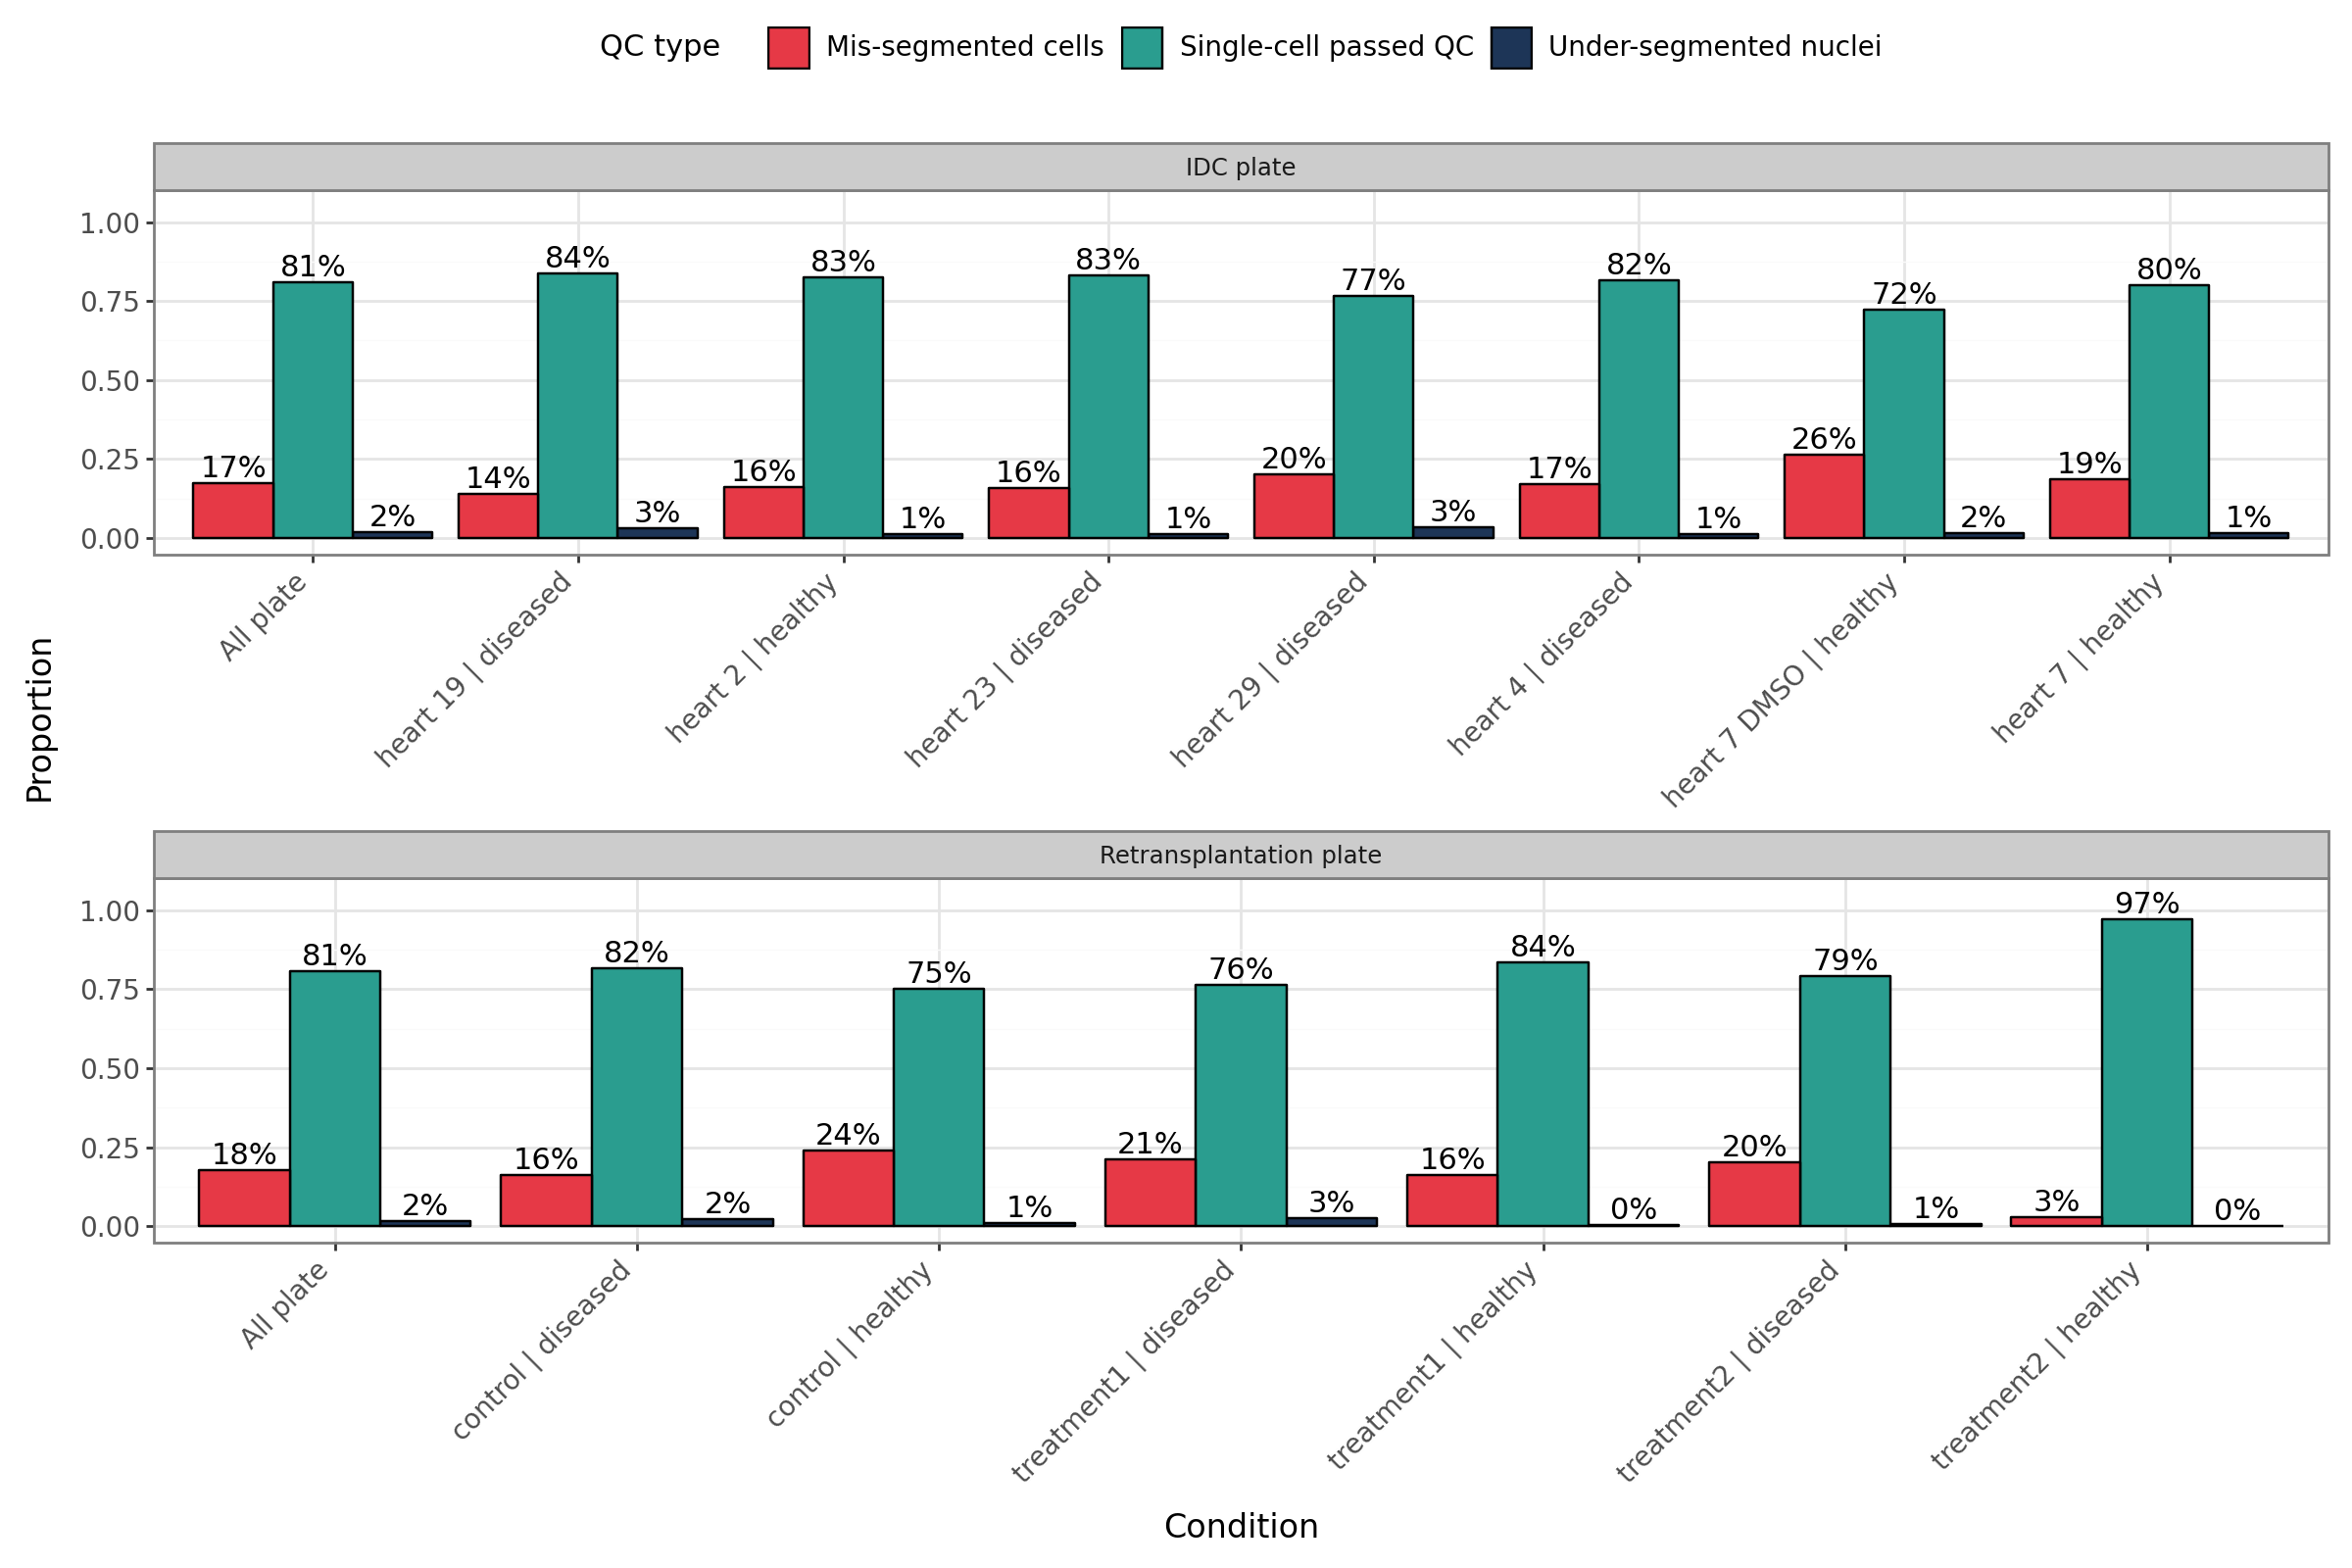

In [22]:
plot_df_long = plot_df.melt(
    id_vars=["Image_Metadata_Plate_Alias", "condition", "n"],
    value_vars=["underseg_rate", "smallcell_rate", "pass_rate"],
    var_name="qc_type",
    value_name="rate",
)

plot_df_long["qc_type"] = plot_df_long["qc_type"].replace(
    {
        "underseg_rate": "Under-segmented nuclei",
        "smallcell_rate": "Mis-segmented cells",
        "pass_rate": "Single-cell passed QC",
    }
)

height = 8
width = 12
set_option("figure_size", (width, height))

p = (
    ggplot(plot_df_long, aes(x="condition", y="rate", fill="qc_type"))
    + geom_bar(stat="identity", position="dodge", color="black")
    + geom_text(
        aes(label="rate"),
        position=position_dodge(width=0.9),
        va="bottom",
        format_string="{:.0%}",
    )
    + facet_wrap("Image_Metadata_Plate_Alias", ncol=1, scales="free_x")
    + scale_fill_manual(values=qc_type_colors)
    + labs(x="Condition", y="Proportion", fill="QC type")
    + ylim(0, 1.05)
    + theme_bw()
    + theme(
        legend_position="top",
        legend_text=element_text(size=10),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        axis_text_x=element_text(rotation=45, hjust=1),
    )
)

p.save(
    f"{figure_dir}/qc_failure_rates_by_plate.png",
    dpi=600,
    width=width,
    height=height,
)

p.show()